In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

## Dataset generation

In [6]:

# 1. MANY XOR TRAINING POINTS
# =========================
N_train = 2000

X_np = np.random.rand(N_train, 2)

y_np = ((X_np[:,0] > 0.5) ^ (X_np[:,1] > 0.5)).astype(float)

# ---- distance to XOR boundary ----
dist_to_boundary = np.minimum(
    np.abs(X_np[:, 0] - 0.5),
    np.abs(X_np[:, 1] - 0.5)
)

# ---- define boundary region ----
epsilon = 0.1
near_boundary = dist_to_boundary < epsilon

# ---- flip labels only near boundary ----
noise_prob = 0.02
flip = (np.random.rand(len(y_np)) < noise_prob) & near_boundary
y_np[flip] = 1 - y_np[flip]

X = torch.tensor(X_np).float()
y = torch.tensor(y_np).unsqueeze(1).float()

## DNN architecture definition

In [7]:
class XORNet(nn.Module):
    def __init__(self, hidden=12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),   # <-- LAST HIDDEN LAYER (2D)
            nn.ReLU(),
            nn.Linear(2, 1)    # output
        )

    def forward(self, x):
        return self.net(x)

    def get_hidden(self, x):
        # Extract representation from the 2D hidden layer
        x = self.net[0](x)
        x = self.net[1](x)
        x = self.net[2](x)  # <-- 2D representation
        return x


In [8]:
model = XORNet(hidden=6)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10000):
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, loss={loss.item():.4f}")


with torch.no_grad():
    H = model.get_hidden(X).numpy()
    labels = y.numpy().flatten()

Epoch 0, loss=0.7754
Epoch 1000, loss=0.3722
Epoch 2000, loss=0.1326
Epoch 3000, loss=0.0816
Epoch 4000, loss=0.0645
Epoch 5000, loss=0.0580
Epoch 6000, loss=0.0555
Epoch 7000, loss=0.0548
Epoch 8000, loss=0.0527
Epoch 9000, loss=0.0524


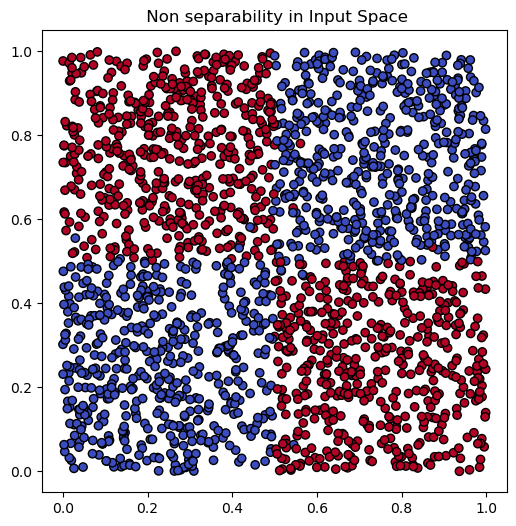

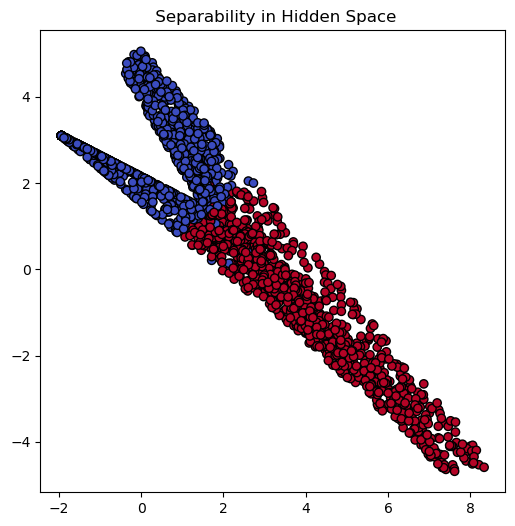

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="coolwarm", edgecolors='k')
plt.title(" Non separability in Input Space")

plt.figure(figsize=(6,6))

plt.scatter(H[:,0], H[:,1], c=labels, cmap="coolwarm", edgecolors='k')
plt.title(" Separability in Embedded Space")
plt.show()
